# ВШЭ 2026: Математические методы анализа данных

## Семинар 2: Разведочный анализ данных (EDA) и подготовка данных

В реальных проектах данные редко бывают идеальными: пропуски, дубликаты и аномалии — норма, а не исключение. Если их не обрабатывать, выводы анализа окажутся ненадёжными, а качество модели — низким.

**План семинара:**
1. Загрузка данных и первый взгляд
2. Обработка пропусков: как обнаружить и чем заполнять (числовые и категориальные признаки)
3. Удаление дубликатов: полные и частичные
4. Поиск выбросов: визуальные и статистические методы; причины аномалий и способы их обработки
5. Корреляционный анализ и визуализация
6. Распределение целевой переменной
7. Train/test split, первая модель, пайплайны sklearn, категориальные признаки

По ходу семинара встречаются **Задачи 1–5** — это самостоятельная работа.

In [1]:
# импортируем библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# стиль графиков
sns.set_theme(style='darkgrid')

import warnings
warnings.filterwarnings('ignore')

#### Установка wget

Чтобы скачать данные из интернета, воспользуемся библиотекой **wget**.

Пакет можно поставить прямо из Jupyter через [pip](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-pip) *magic-команду* — она установит пакет для текущего ядра Python (в отличие от `!pip`, который может попасть в другой интерпретатор).

In [2]:
%pip install -q wget

  Preparing metadata (setup.py) ... done


Теперь скачаем датасет для сегодняшнего занятия:

In [3]:
# импортируем библиотеку
import wget

# ссылка на файл
url = 'https://docs.google.com/uc?export=download&id=1k21iUIrz0NjfiLE_j-oBQm1bNu3wASX6'

# скачиваем файл и сохраняем его имя в переменную
filename = wget.download(url)

# печатаем имя файла
filename

'train_home_price.csv'

## Датасет House Prices

Мы будем работать с датасетом о ценах на дома.

**Описание датасета**

Попросите покупателя описать дом мечты — вряд ли он начнёт с высоты потолка в подвале или близости к железной дороге. Но этот датасет показывает, что на цену влияет куда больше факторов, чем число спален и белый заборчик.

79 признаков описывают (почти) каждый аспект жилых домов в городе Эймс, штат Айова; задача соревнования — предсказать итоговую цену продажи.

Подробности, чужие решения и код — на <a href="https://www.kaggle.com/c/house-prices-advanced-regression-techniques">Kaggle</a>.

In [4]:
# читаем данные с диска; первый столбец (Id) делаем индексом
data = pd.read_csv(filename, index_col=0)

# копия исходных данных — пригодится в Задачах 1–2, чтобы не зависеть от наших правок
data_raw = data.copy()

# первые 5 строк таблицы
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# одна строка целиком — так удобнее прочитать все признаки одного дома
data.iloc[0]

,1
MSSubClass,60
MSZoning,RL
LotFrontage,65.0
LotArea,8450
Street,Pave
...,...
MoSold,2
YrSold,2008
SaleType,WD
SaleCondition,Normal


Посмотрим полный список признаков:

In [6]:
data.columns.tolist()

['MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF',
 'Enc

Как видим, их довольно много. Сколько именно?

In [7]:
data.shape

(1460, 80)

**Полное описание признаков** (оставляем на английском — так они называются в данных и на Kaggle):
    
* **SalePrice:** the property's sale price in dollars. This is the **target variable** that you're trying to predict.

* **MSSubClass:** The building class
* **MSZoning:** The general zoning classification
* **LotFrontage:** Linear feet of street connected to property
* **LotArea:** Lot size in square feet
* **Street:** Type of road access
* **Alley:** Type of alley access
* **LotShape:** General shape of property
* **LandContour:** Flatness of the property
* **Utilities:** Type of utilities available
* **LotConfig:** Lot configuration
* **LandSlope:** Slope of property
* **Neighborhood:** Physical locations within Ames city limits
* **Condition1:** Proximity to main road or railroad
* **Condition2:** Proximity to main road or railroad (if a second is present)
* **BldgType:** Type of dwelling
* **HouseStyle:** Style of dwelling
* **OverallQual:** Overall material and finish quality
* **OverallCond:** Overall condition rating
* **YearBuilt:** Original construction date
* **YearRemodAdd:** Remodel date
* **RoofStyle:** Type of roof
* **RoofMatl:** Roof material
* **Exterior1st:** Exterior covering on house
* **Exterior2nd:** Exterior covering on house (if more than one material)
* **MasVnrType:** Masonry veneer type
* **MasVnrArea:** Masonry veneer area in square feet
* **ExterQual:** Exterior material quality
* **ExterCond:** Present condition of the material on the exterior
* **Foundation:** Type of foundation
* **BsmtQual:** Height of the basement
* **BsmtCond:** General condition of the basement
* **BsmtExposure:** Walkout or garden level basement walls
* **BsmtFinType1:** Quality of basement finished area
* **BsmtFinSF1:** Type 1 finished square feet
* **BsmtFinType2:** Quality of second finished area (if present)
* **BsmtFinSF2:** Type 2 finished square feet
* **BsmtUnfSF:** Unfinished square feet of basement area
* **TotalBsmtSF:** Total square feet of basement area
* **Heating:** Type of heating
* **HeatingQC:** Heating quality and condition
* **CentralAir:** Central air conditioning
* **Electrical:** Electrical system
* **1stFlrSF:** First Floor square feet
* **2ndFlrSF:** Second floor square feet
* **LowQualFinSF:** Low quality finished square feet (all floors)
* **GrLivArea:** Above grade (ground) living area square feet
* **BsmtFullBath:** Basement full bathrooms
* **BsmtHalfBath:** Basement half bathrooms
* **FullBath:** Full bathrooms above grade
* **HalfBath:** Half baths above grade
* **Bedroom:** Number of bedrooms above basement level
* **Kitchen:** Number of kitchens
* **KitchenQual:** Kitchen quality
* **TotRmsAbvGrd:** Total rooms above grade (does not include bathrooms)
* **Functional:** Home functionality rating
* **Fireplaces:** Number of fireplaces
* **FireplaceQu:** Fireplace quality
* **GarageType:** Garage location
* **GarageYrBlt:** Year garage was built
* **GarageFinish:** Interior finish of the garage
* **GarageCars:** Size of garage in car capacity
* **GarageArea:** Size of garage in square feet
* **GarageQual:** Garage quality
* **GarageCond:** Garage condition
* **PavedDrive:** Paved driveway
* **WoodDeckSF:** Wood deck area in square feet
* **OpenPorchSF:** Open porch area in square feet
* **EnclosedPorch:** Enclosed porch area in square feet
* **3SsnPorch:** Three season porch area in square feet
* **ScreenPorch:** Screen porch area in square feet
* **PoolArea:** Pool area in square feet
* **PoolQC:** Pool quality
* **Fence:** Fence quality
* **MiscFeature:** Miscellaneous feature not covered in other categories
* **MiscVal:** Value of miscellaneous feature
* **MoSold:** Month Sold
* **YrSold:** Year Sold
* **SaleType:** Type of sale
* **SaleCondition:** Condition of sale

Проверим типы данных:

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

# Обработка пропусков

Как видим, много категориальных признаков. При этом качество данных вызывает вопросы — слишком много пропущенных значений. Посмотрим, сколько конкретно (доля пропусков в каждом столбце):

In [9]:
# .mean() по булевой маске isna() = доля пропусков в столбце
na_share = data.isna().mean()
na_share[na_share > 0].sort_values(ascending=False).round(2)

,0
PoolQC,1.00
MiscFeature,0.96
Alley,0.94
Fence,0.81
MasVnrType,0.60
FireplaceQu,0.47
LotFrontage,0.18
GarageType,0.06
GarageYrBlt,0.06
GarageFinish,0.06


Что можно сделать с **пропусками**?

- **1. Удалить**
    - весь столбец
    - строку

- **2. Заполнить**:
    - статистикой: среднее / мода / медиана / max / min / квантили и т.д.
    - с помощью ML: столбец с пропусками — целевая переменная, обучаем модель на остальных и предсказываем пропуски
    - константой, hot/cold deck imputation, интерполяцией

Ключевой вопрос перед любым заполнением: **пропуск — это отсутствие информации или отсутствие объекта?** Ответ часто есть в описании данных.

С признаками, где пропусков слишком много, работать невозможно — удалим их:

In [10]:
list_to_drop = na_share[na_share > 0.3].index.tolist()
list_to_drop

['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']

In [11]:
data = data.drop(columns=list_to_drop)

Для остальных признаков сначала попробуем просто выкинуть строки с пропусками и посмотрим, сколько данных останется:

In [12]:
data.dropna().shape[0] / data.shape[0]

0.7493150684931507

Осталось бы примерно 75% данных. Неплохо, приемлемый вариант.

Можно ли лучше?

Посмотрим, сколько данных останется, если мы найдём, чем заполнить пропуски в признаке `LotFrontage`:

In [13]:
data_ = data.copy()
# присваиваем результат, а не fillna(inplace=True) по срезу: цепочка «срез + inplace» в новых pandas не работает
data_['LotFrontage'] = data_['LotFrontage'].fillna(9999999)
data_.dropna().shape[0] / data.shape[0]

0.9164383561643835

Ого! Останется 92% данных.

Посмотрим, чем можно заполнить пропуски:

Описание признака:
    
* LotFrontage: Linear feet of street connected to property (длина участка вдоль улицы, в футах)

Посмотрим на корреляцию `LotFrontage` с целевой переменной `SalePrice`:

In [14]:
data.LotFrontage.corr(data.SalePrice)

np.float64(0.35179909657067804)

Как изменится корреляция, если заполнять пропуски разными способами?

In [15]:
list_to_check = [0, data.LotFrontage.min(), data.LotFrontage.max(), data.LotFrontage.mean(), data.LotFrontage.median(),
                 data.LotFrontage.quantile(0.1), data.LotFrontage.quantile(0.25), data.LotFrontage.quantile(0.75),
                 data.LotFrontage.quantile(0.9)]

list_of_names = ['0', 'min', 'max', 'mean', 'median', 'quantile 0.1', 'quantile 0.25', 'quantile 0.75', 'quantile 0.9']
list_of_methods = ['bfill', 'ffill']

In [16]:
for value, name in zip(list_to_check, list_of_names):
    print('метод: {:<14} корреляция: {:.4f}'.format(name, data.LotFrontage.fillna(value).corr(data.SalePrice)))

# fillna(method=...) объявлен устаревшим — используем методы .bfill() / .ffill()
for name in list_of_methods:
    filled = getattr(data.LotFrontage, name)()
    print('метод: {:<14} корреляция: {:.4f}'.format(name, filled.corr(data.SalePrice)))

метод: 0              корреляция: 0.2096
метод: min            корреляция: 0.2524
метод: max            корреляция: 0.0813
метод: mean           корреляция: 0.3349
метод: median         корреляция: 0.3348
метод: quantile 0.1   корреляция: 0.3035
метод: quantile 0.25  корреляция: 0.3281
метод: quantile 0.75  корреляция: 0.3307
метод: quantile 0.9   корреляция: 0.3071
метод: bfill          корреляция: 0.3028
метод: ffill          корреляция: 0.2985


Среднее, медиана и квантили лучше сохраняют корреляцию.

Но, может быть, можно ещё лучше? Посмотрим на графики:

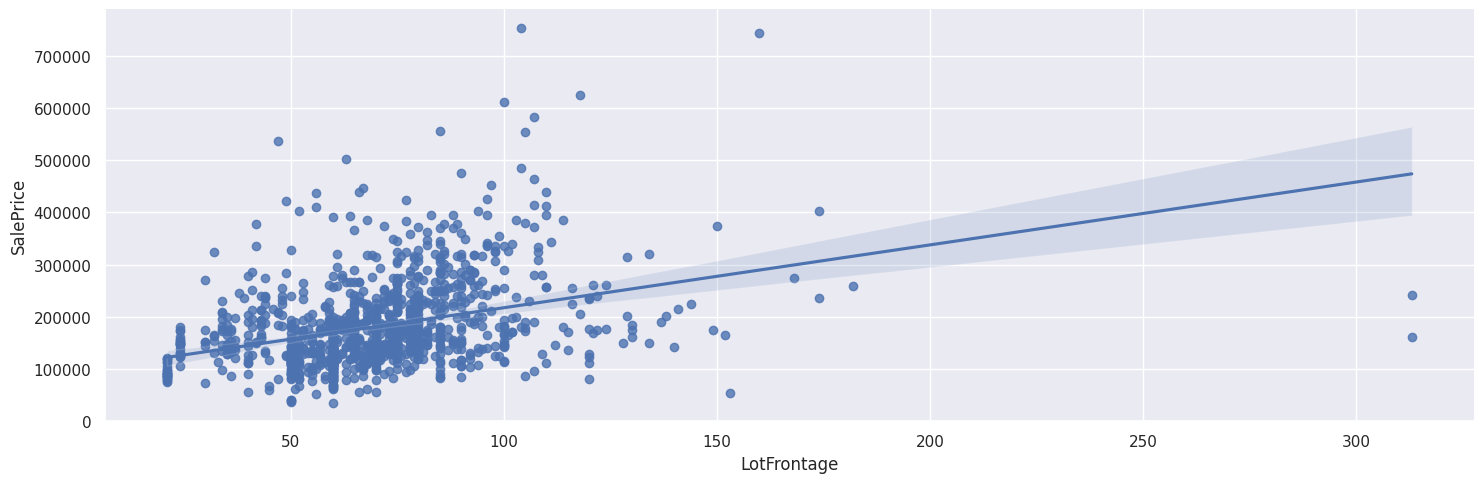

In [17]:
sns.lmplot(data=data, x='LotFrontage', y='SalePrice', aspect=3, height=5)
plt.show()

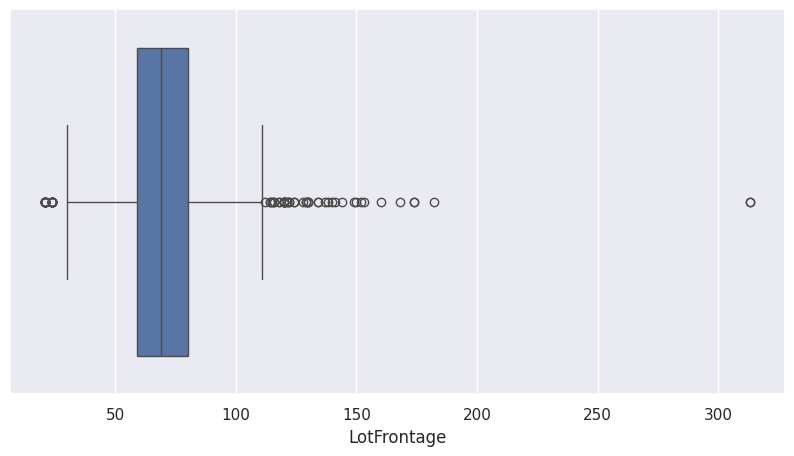

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(data = data, x = 'LotFrontage')
plt.show()

Идея: разобьём целевую переменную на группы по квантилям (например, по 10%) и посмотрим на распределение `LotFrontage` внутри этих групп.

In [19]:
price_bins = data.SalePrice.quantile([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
price_bins

,SalePrice
0.0,34900.0
0.1,106475.0
0.2,124000.0
0.3,135500.0
0.4,147000.0
0.5,163000.0
0.6,179280.0
0.7,198620.0
0.8,230000.0
0.9,278000.0


In [20]:
data['PriceGroups'] = pd.cut(data['SalePrice'], price_bins,
                             labels=['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5',
                                     '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1'],
                             right=True, include_lowest=True)

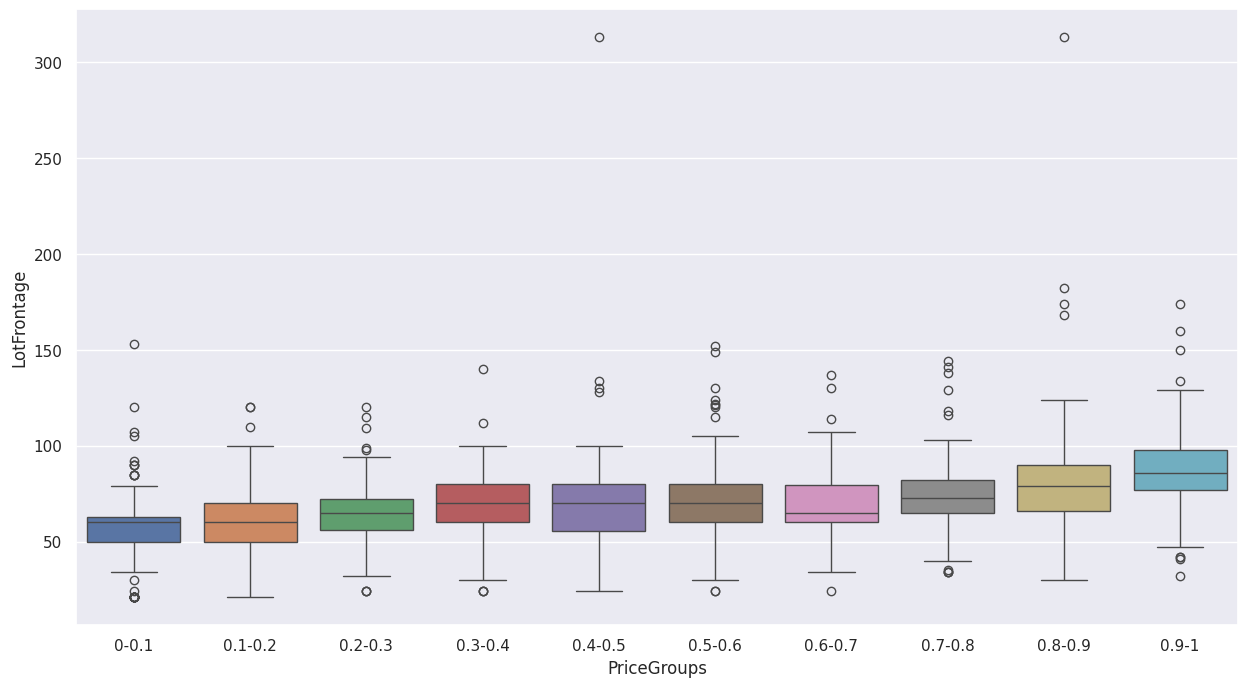

In [21]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=data, y='LotFrontage', x='PriceGroups', hue='PriceGroups', legend=False)
plt.show()

Посмотрим, какой будет корреляция, если заполнить пропуски средним **внутри каждой ценовой группы**:

In [22]:
data.groupby('PriceGroups', observed=True).LotFrontage.mean()

,LotFrontage
PriceGroups,
0-0.1,56.362963
0.1-0.2,61.038760
0.2-0.3,64.480916
0.3-0.4,68.686441
0.4-0.5,68.909091
0.5-0.6,71.935185
0.6-0.7,68.783784
0.7-0.8,73.830357
0.8-0.9,81.565217


In [23]:
# transform возвращает Series той же длины, что и data: в каждой группе своё среднее
filled_by_group = data.groupby('PriceGroups', observed=True).LotFrontage.transform(lambda x: x.fillna(x.mean())).round(0)
filled_by_group.corr(data.SalePrice)

np.float64(0.36942232876896147)

Корреляция выросла. Остановимся на этом варианте.

⚠️ Важная оговорка: мы заполняем признак, **используя целевую переменную**. Для EDA это нормально, но в ML-пайплайне так делать нельзя — на новых данных цены мы не знаем, и это утечка таргета. Там группируют по признакам, которые есть всегда (например, `Neighborhood` или `MSZoning` — см. Задачу 2).

In [24]:
data['LotFrontage'] = filled_by_group

Доля пропусков по признакам сейчас:

In [25]:
na_share = data.isna().mean()
na_share[na_share > 0].sort_values(ascending=False)

,0
GarageYrBlt,0.055479
GarageFinish,0.055479
GarageQual,0.055479
GarageType,0.055479
GarageCond,0.055479
BsmtFinType2,0.026027
BsmtExposure,0.026027
BsmtQual,0.025342
BsmtFinType1,0.025342
BsmtCond,0.025342


### Пропуски в категориальных признаках

Для чисел мы подбирали константу (среднее, медиана). Для категорий это не работает — «среднего» у категорий нет. Типовые варианты:

* **Заполнить по смыслу.** В описании датасета сказано: `NA` в `BsmtQual`, `GarageType` и т.п. означает **«нет подвала / нет гаража»**. Это не потерянное значение, а отдельная полноценная категория — так и запишем: `'None'`.
* **Заполнить модой** (самым частым значением) — когда пропусков мало и они действительно случайны (`Electrical`: 1 пропуск).
* **Отдельная категория `'Unknown'`** — когда причина неизвестна, но выкидывать строки жалко: модель сама решит, значим ли факт пропуска.

Ключевой вопрос перед любым заполнением: **пропуск — это отсутствие информации или отсутствие объекта?**

In [26]:
# exclude='number' работает одинаково в pandas 2 и 3 (там строки стали отдельным dtype 'str')
cat = data.select_dtypes(exclude='number')
cat_cols_na = cat.columns[cat.isna().any()].tolist()
print('Категориальные признаки с пропусками:', cat_cols_na)

# 1) NA = 'объекта нет' -> отдельная категория
meaning_none = [c for c in cat_cols_na if c.startswith(('Bsmt', 'Garage', 'MasVnr'))]
data[meaning_none] = data[meaning_none].fillna('None')

# 2) редкий случайный пропуск -> мода
if 'Electrical' in cat_cols_na:
    data['Electrical'] = data['Electrical'].fillna(data['Electrical'].mode()[0])

na_share = data.isna().mean()
na_share[na_share > 0].sort_values(ascending=False)

Категориальные признаки с пропусками: ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']


,0
GarageYrBlt,0.055479
MasVnrArea,0.005479


Остались пропуски только в числовых признаках (`GarageYrBlt`, `MasVnrArea`). Их можно заполнить, проведя анализ как для `LotFrontage`, либо просто выкинуть строки. Здесь выкинем, а вам:
    
### Задача 1

Исследуйте, чем можно заполнить оставшиеся пропуски (`GarageYrBlt`, `MasVnrArea`), и покажите, как это влияет на корреляцию с целевой переменной.

In [ ]:
# data = data.dropna()
# data.shape

# ваш код здесь

(1371, 75)

Посмотрим на распределение `LotFrontage` по зонам застройки:

In [28]:
data.MSZoning.unique()

array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object)

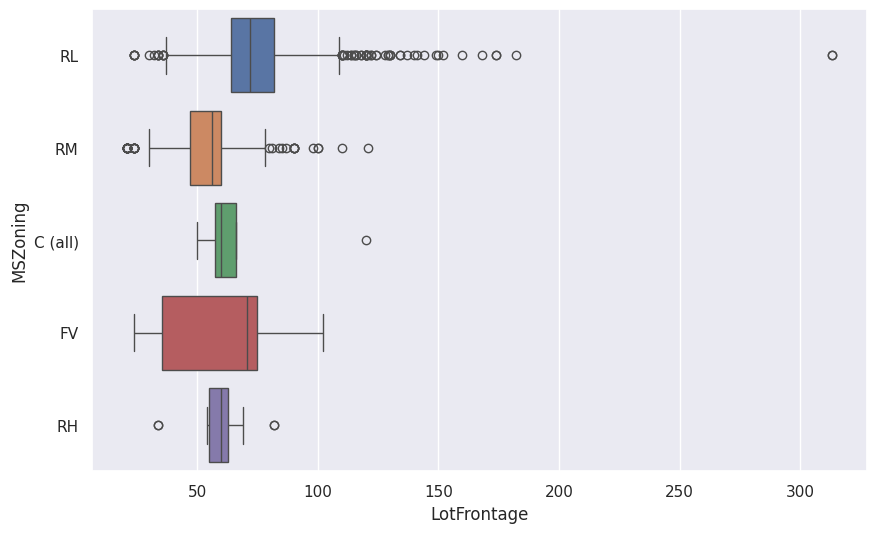

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='LotFrontage', y='MSZoning', hue='MSZoning')
plt.show()

### Задача 2

Возьмите исходные данные (`data_raw`) и заполните пропуски в `LotFrontage` статистикой (среднее/медиана) **по зонам `MSZoning`**. Сравните корреляцию с `SalePrice` с тем, что мы получили при заполнении по ценовым группам. Какой способ можно использовать в ML-пайплайне, а какой — нет, и почему?

In [ ]:
# ваш код здесь

# Удаление дубликатов

Дубликаты возникают при повторной выгрузке, склейке источников, ретраях в пайплайне. Они опасны тем, что **завышают вес одних наблюдений**: модель «переобучается» на повторах, а метрики на тесте становятся оптимистичными, если копия попала и в train, и в test.

Различают:
* **Полные дубликаты** — строки совпадают по всем столбцам. Их почти всегда можно удалять.
* **Частичные (неявные) дубликаты** — совпадает набор *ключевых* признаков, а остальные отличаются (например, тот же дом, но другая дата/цена выгрузки). Здесь нужно решать, какую версию оставить: первую, последнюю или агрегировать.

Инструменты: `duplicated()` находит, `drop_duplicates()` удаляет; параметр `subset` задаёт «ключ», `keep` — какую копию оставить.

In [30]:
print('Полных дубликатов в данных:', data.duplicated().sum())

# В этом датасете дублей нет (индекс — уникальный Id). Смоделируем ситуацию:
# «случайно» повторно выгрузили 5 строк
data_dup = pd.concat([data, data.sample(5, random_state=0)])
print('После «повторной выгрузки»:', data_dup.shape, '| полных дубликатов:', data_dup.duplicated().sum())

# keep='first' (по умолчанию) оставляет первое вхождение; keep=False — пометит ВСЕ копии
data_dup[data_dup.duplicated(keep=False)].sort_index().head(4)

Полных дубликатов в данных: 0
После «повторной выгрузки»: (1376, 75) | полных дубликатов: 5


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,PriceGroups
Id,,,,,,,,,,,,,,,,,,,,,
32,20,RL,69.0,8544,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,6,2008,WD,Normal,149350,0.4-0.5
32,20,RL,69.0,8544,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,6,2008,WD,Normal,149350,0.4-0.5
273,60,RL,92.0,11764,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,4,2010,WD,Normal,290000,0.9-1
273,60,RL,92.0,11764,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,4,2010,WD,Normal,290000,0.9-1


In [31]:
# Полные дубликаты — просто удаляем
data_dedup = data_dup.drop_duplicates()
print('После drop_duplicates:', data_dedup.shape)

# Частичные дубликаты: считаем «одним и тем же домом» совпадение по ключевым признакам.
key = ['Neighborhood', 'LotArea', 'YearBuilt', 'GrLivArea', 'OverallQual']
partial = data[data.duplicated(subset=key, keep=False)].sort_values(key)
print('Строк с частичным совпадением по ключу:', len(partial))
partial[key + ['SalePrice', 'YrSold']].head(6)

После drop_duplicates: (1371, 75)
Строк с частичным совпадением по ключу: 31


,Neighborhood,LotArea,YearBuilt,GrLivArea,OverallQual,SalePrice,YrSold
Id,,,,,,,
1005,Blmngtn,3182,2005,1504,7,181000,2009
1024,Blmngtn,3182,2005,1504,7,191000,2008
236,BrDale,1680,1971,987,6,89500,2008
431,BrDale,1680,1971,987,6,85400,2008
233,BrDale,1680,1972,987,6,94500,2006
364,BrDale,1680,1972,987,6,118000,2009


Одинаковые дома с разной ценой и годом продажи — это, скорее всего, **повторная продажа**, а не ошибка. Такие «дубли» удалять нельзя без разбора: сначала смотрим, откуда они взялись. Если бы это была ошибка выгрузки, мы бы оставили последнюю версию: `drop_duplicates(subset=key, keep='last')`.

# Поиск выбросов: визуальные методы

Посмотрим на распределение цен на дома:

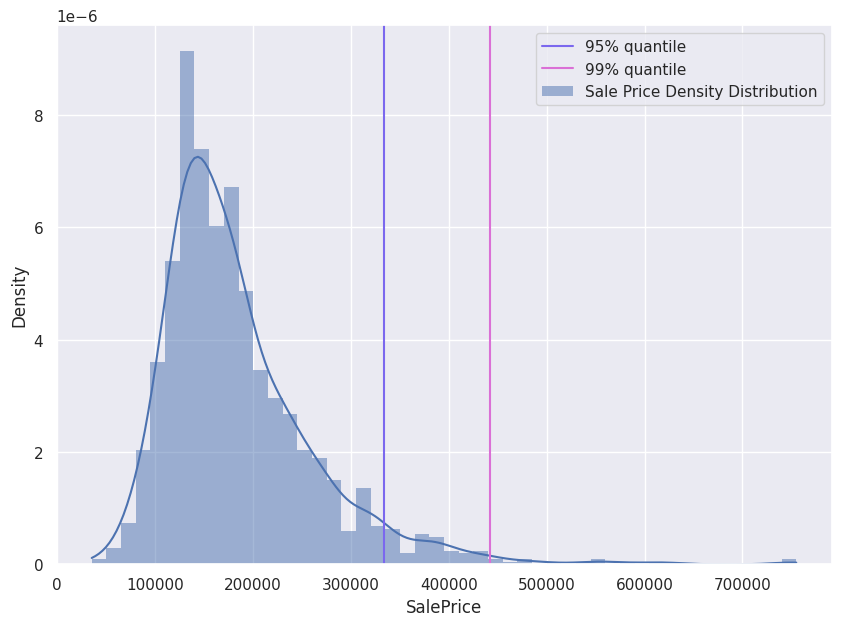

In [32]:
plt.subplots(figsize=(10,7))
sns.histplot(data['SalePrice'], label='Sale Price Density Distribution', kde=True, stat="density", linewidth=0)
plt.axvline(data.SalePrice.quantile(0.95), label='95% quantile', c='mediumslateblue')
plt.axvline(data.SalePrice.quantile(0.99), label='99% quantile', c='orchid')
plt.legend()
plt.show()

На графике видим длинный тонкий хвост справа — там лежат «выбросы», точки за 95-м и 99-м квантилями.

Имеет смысл их отбросить:

In [33]:
data = data.loc[data.SalePrice < data.SalePrice.quantile(0.99)]
data.shape

(1357, 75)

Теперь посмотрим на распределение цен по зонам:

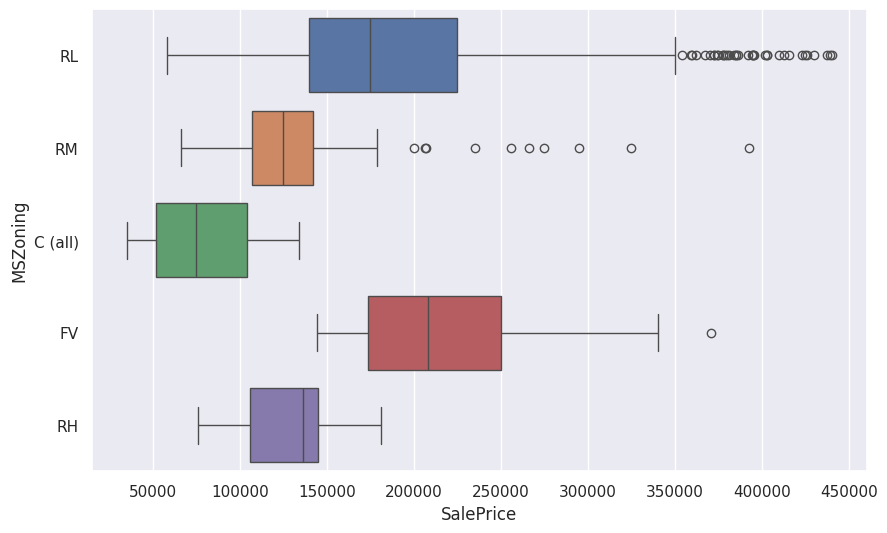

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='SalePrice', y='MSZoning', hue='MSZoning')
plt.show()

## Статистические методы поиска выбросов

Глазами мы смотрели на гистограмму и boxplot. Но когда признаков десятки, нужны формальные правила. Два самых ходовых:

* **Правило межквартильного размаха (IQR)** — то самое, по которому boxplot рисует «усы». Выброс — всё, что дальше $1.5 \cdot IQR$ от квартилей: $x < Q_1 - 1.5\,IQR$ или $x > Q_3 + 1.5\,IQR$. Устойчиво к самим выбросам, не требует нормальности.
* **Z-score** — сколько стандартных отклонений от среднего: $z = \frac{x - \mu}{\sigma}$, выброс при $|z| > 3$. Простое, но среднее и $\sigma$ сами «тянутся» за выбросами, поэтому для сильно скошенных данных лучше IQR (или робастный z-score на медиане и MAD).

Проверим на площади дома `GrLivArea` — в этом датасете там есть знаменитые аномалии.

GrLivArea: IQR нашёл 24 выбросов, z-score — 10


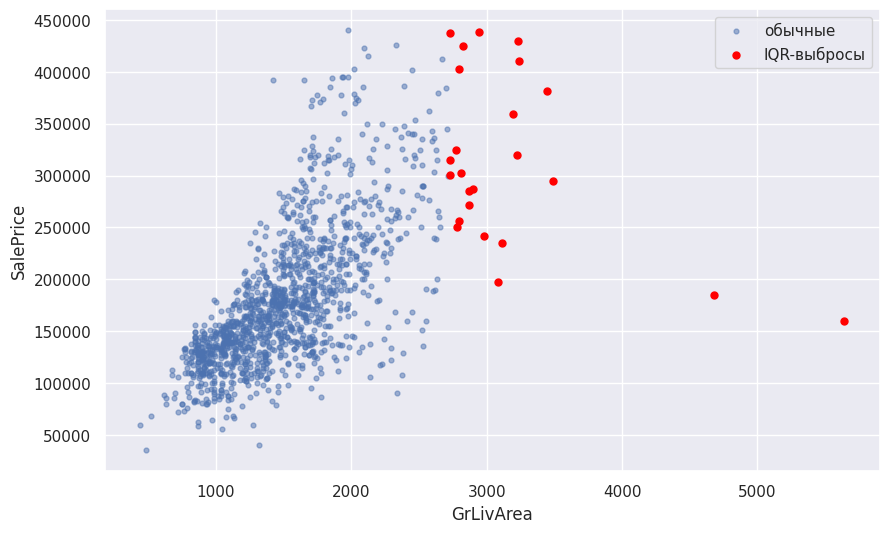

In [35]:
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)

def zscore_outliers(s, thr=3):
    return ((s - s.mean()) / s.std()).abs() > thr

col = 'GrLivArea'
mask_iqr, mask_z = iqr_outliers(data[col]), zscore_outliers(data[col])
print(f'{col}: IQR нашёл {mask_iqr.sum()} выбросов, z-score — {mask_z.sum()}')

# Выброс в одном измерении - ещё не аномалия. Смотрим признак ВМЕСТЕ с целевой:
plt.figure(figsize=(10, 6))
plt.scatter(data[col], data.SalePrice, s=12, alpha=0.5, label='обычные')
plt.scatter(data.loc[mask_iqr, col], data.loc[mask_iqr, 'SalePrice'], s=25, c='red', label='IQR-выбросы')
plt.xlabel(col); plt.ylabel('SalePrice'); plt.legend(); plt.show()

Обратите внимание на точки справа внизу: **огромная площадь при низкой цене**. По одной только площади они — просто «большие дома», а вот в паре с ценой — явная аномалия (в описании Ames Housing автор датасета прямо рекомендует их удалить: это частичные продажи). Урок: одномерные правила — фильтр первого уровня, финальное решение принимается с учётом контекста.

# Причины появления аномалий и способы их обработки

Прежде чем что-то удалять, стоит ответить на вопрос **«откуда взялась аномалия?»** — от ответа зависит, что с ней делать.

| Причина | Пример | Что делать |
|---|---|---|
| Ошибка ввода / опечатка | площадь 100 000 вместо 1 000 | исправить, если можно восстановить; иначе удалить |
| Ошибка единиц измерения | цена в тысячах у части записей | привести к одной шкале |
| Сбой сборки данных | дефолтные `-1`, `0`, `9999` вместо NaN | заменить на NaN и обработать как пропуск |
| Редкое, но **реальное** событие | продажа особняка, VIP-клиент | **оставить** — это и есть сигнал; удаление исказит картину |
| Другой процесс генерации данных | частичная продажа дома, тестовые аккаунты | удалить или вынести в отдельную выборку |

Основные способы обработки:

1. **Удаление** — просто и честно, если аномалий мало и они точно ошибочны. Мы так сделали с 1% самых дорогих домов.
2. **Ограничение (винзоризация, `clip`)** — не выкидываем строку, а «прижимаем» значение к границе, например к 1-му и 99-му перцентилю. Сохраняем наблюдение, убираем экстремальность.
3. **Монотонное преобразование** (`log`, `sqrt`) — сжимает хвост, выброс остаётся, но перестаёт доминировать. Это сделаем в следующем разделе.
4. **Флаг-признак** — оставляем значение, а рядом добавляем `is_outlier = 1`. Модель сама решит, важен ли этот факт.
5. **Робастные методы** — медиана вместо среднего, `RobustScaler`, деревья вместо линейных моделей: менее чувствительны к выбросам.

Покажем варианты 2 и 4 на `GrLivArea`.

In [36]:
# считаем на копии, чтобы служебные столбцы не попали потом в модель
demo = data[['GrLivArea']].copy()

# 2) винзоризация: прижимаем к 1-му и 99-му перцентилю
lo, hi = demo['GrLivArea'].quantile([0.01, 0.99])
demo['GrLivArea_clipped'] = demo['GrLivArea'].clip(lower=lo, upper=hi)

# 4) флаг выброса вместо удаления
demo['GrLivArea_is_outlier'] = iqr_outliers(demo['GrLivArea']).astype(int)

print(f'Границы clip: [{lo:.0f}, {hi:.0f}]')
print('Помечено как выброс:', demo['GrLivArea_is_outlier'].sum())
demo.describe().round(1)

Границы clip: [750, 2872]
Помечено как выброс: 24


,GrLivArea,GrLivArea_clipped,GrLivArea_is_outlier
count,1357.0,1357.0,1357.0
mean,1517.6,1513.0,0.0
std,493.2,465.5,0.1
min,438.0,749.8,0.0
25%,1148.0,1148.0,0.0
50%,1475.0,1475.0,0.0
75%,1776.0,1776.0,0.0
max,5642.0,2872.0,1.0


# Корреляционный анализ

Как все признаки коррелируют с ценой и друг с другом?

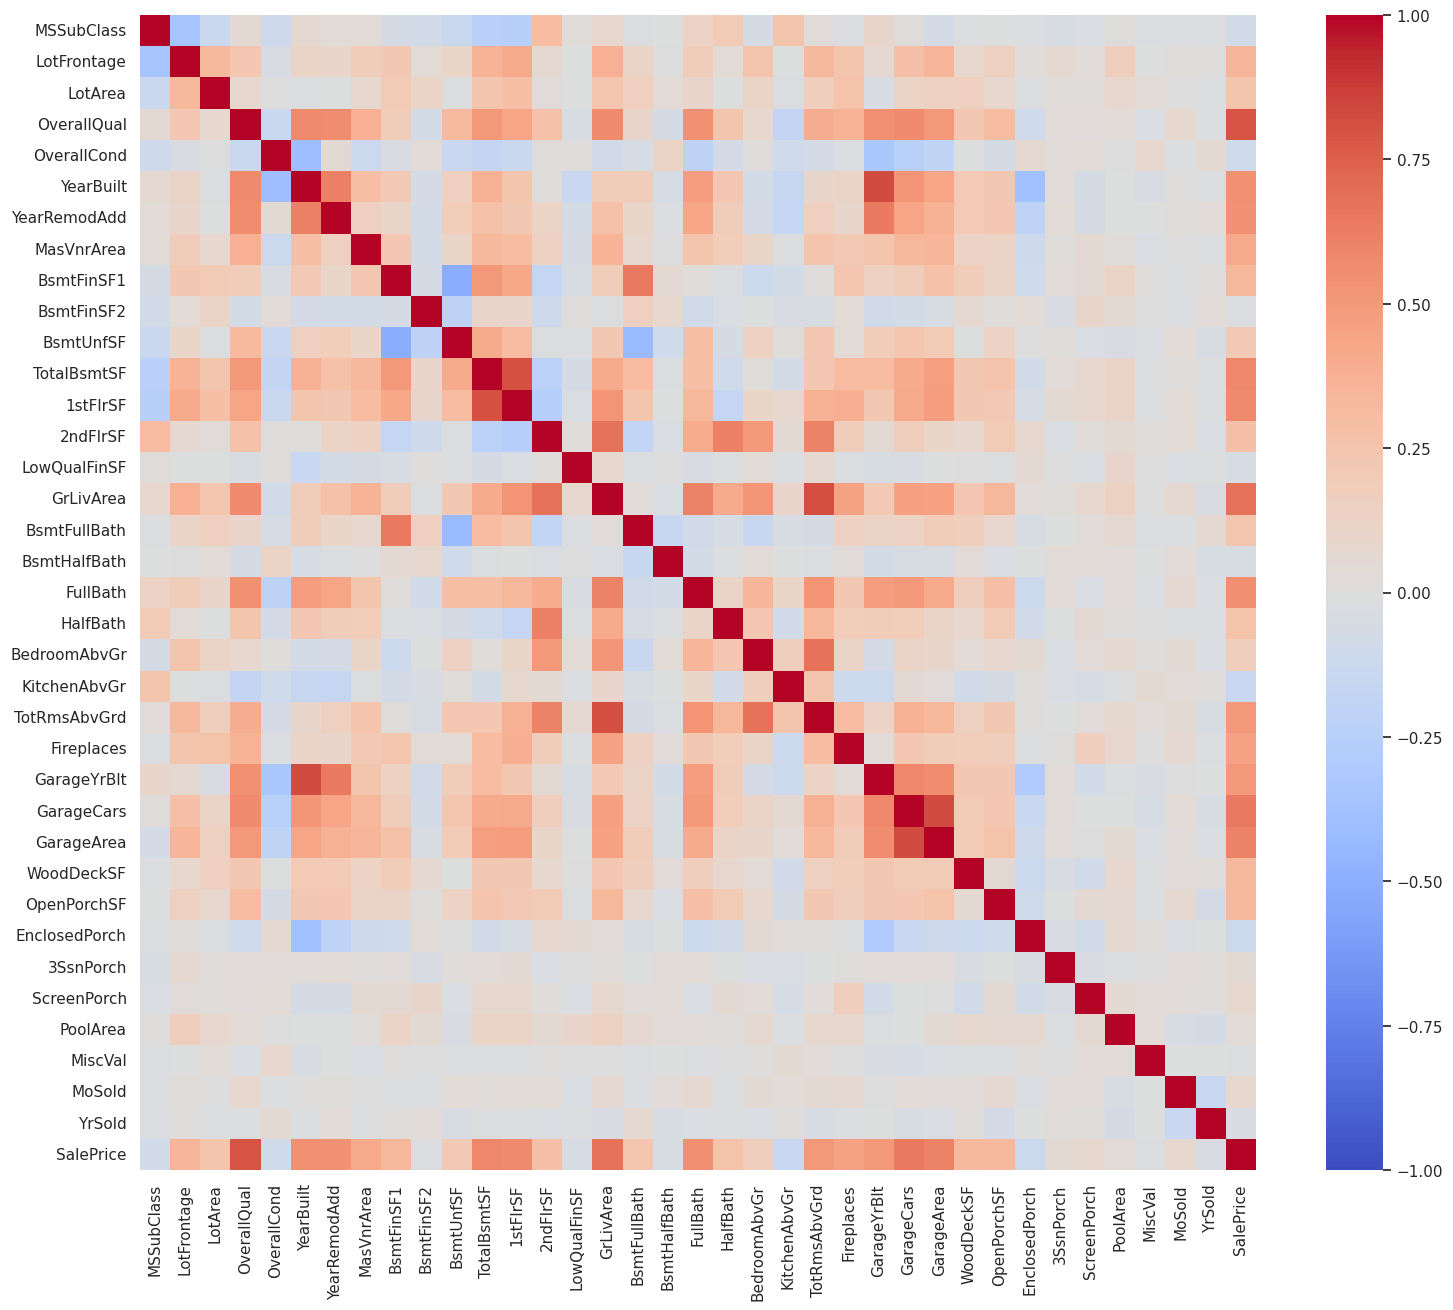

In [37]:
plt.subplots(figsize=(18, 15))
sns.heatmap(data.select_dtypes('number').corr(), cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.show()

Это ровно тот случай, когда признаков слишком много и график становится нечитаемым. Тогда можно рисовать по группам признаков или смотреть только top-k по корреляции с таргетом:

In [38]:
k = 8
corrmat = data.select_dtypes('number').corr()
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index.tolist()
cols

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'FullBath']

In [39]:
corrmat.nlargest(k, 'SalePrice')['SalePrice']

,SalePrice
SalePrice,1.000000
OverallQual,0.792892
GrLivArea,0.676308
GarageCars,0.642289
GarageArea,0.607741
TotalBsmtSF,0.581330
1stFlrSF,0.572664
FullBath,0.551339


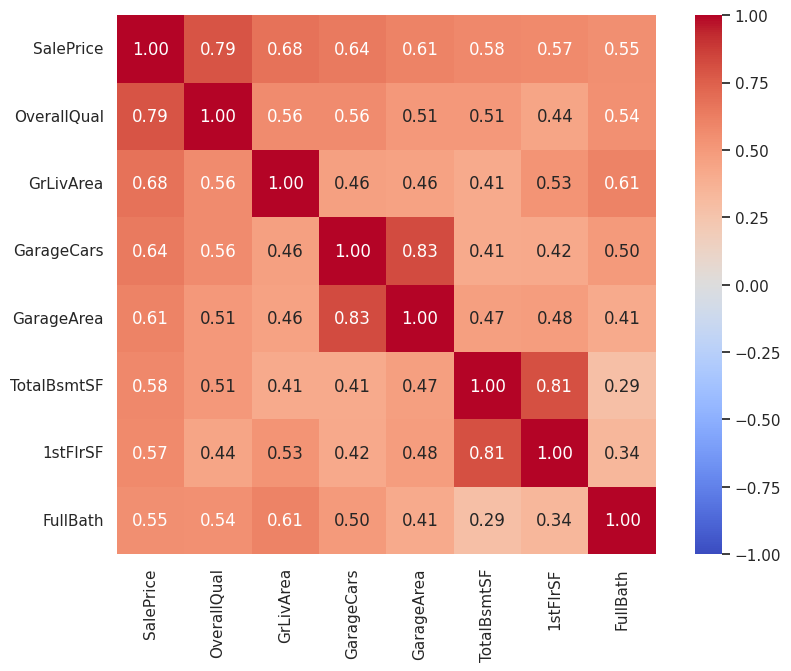

In [40]:
cm = np.corrcoef(data[cols].values.T)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 12},
            yticklabels=cols, xticklabels=cols, vmin=-1, vmax=1, center=0, cmap='coolwarm')
plt.show()

Обратите внимание на пары `GarageCars`–`GarageArea` и `TotalBsmtSF`–`1stFlrSF`: корреляция ~0.8–0.9. Это **мультиколлинеарность** — признаки дублируют друг друга, что для линейной регрессии вредно (коэффициенты становятся неустойчивыми).

Теперь посмотрим на попарные зависимости для top-8 признаков:

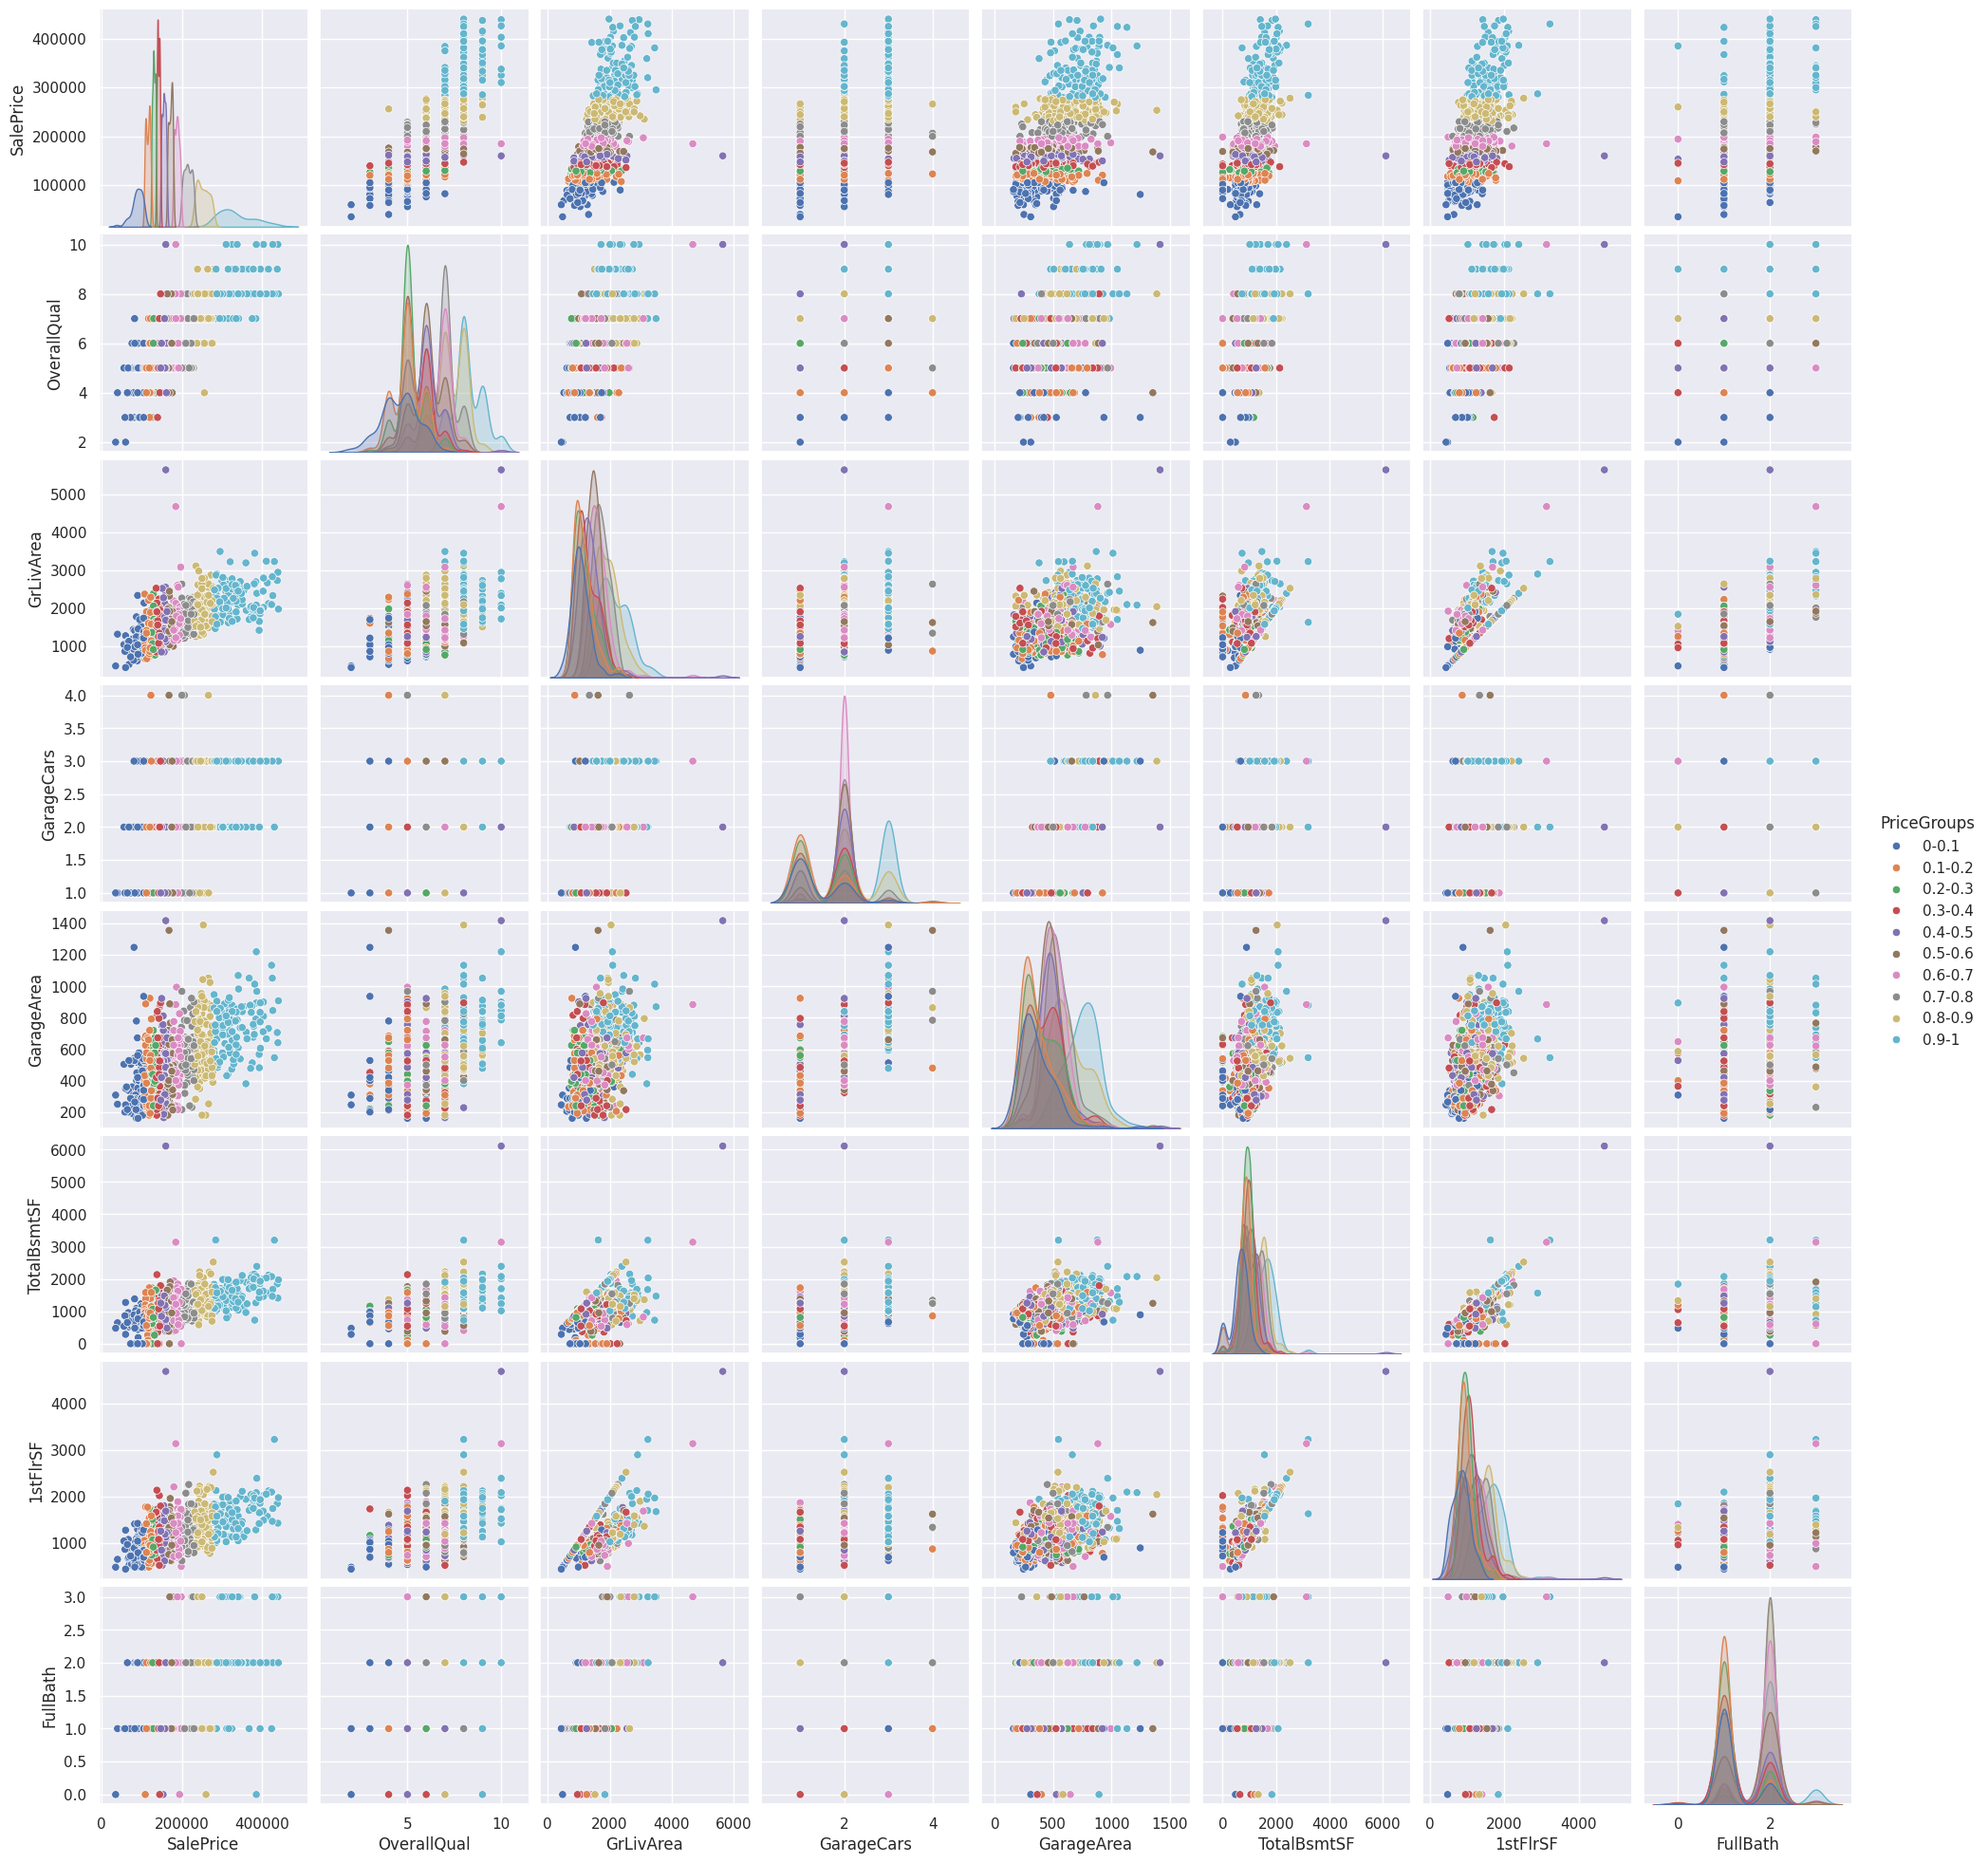

In [41]:
# pairplot на 8 признаках и 10 группах рисуется долго (~1 мин) и получается нечитаемым — это намеренно, см. Задачу 3
sns.pairplot(data=data[cols + ['PriceGroups']], hue='PriceGroups')
plt.show()

Графики выше плохо читаются по двум причинам: во-первых, слишком много признаков нарисовано сразу, во-вторых, разбиение на группы слишком дробное.

### Задача 3

Перерисуйте график выше, раскрасив точки по разбиению целевой переменной на 4–5 квантилей, и нарисуйте только top-5 признаков по корреляции.

In [ ]:
# ваш код здесь

Описательные статистики top-5 признаков по корреляции:

In [42]:
data[['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea']].describe()

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea
count,1357.000000,1357.000000,1357.000000,1357.000000,1357.000000
mean,181347.570376,6.147384,1517.644068,1.857775,496.818718
std,68910.551727,1.308167,493.211371,0.623738,183.149977
min,35311.000000,2.000000,438.000000,1.000000,160.000000
25%,133500.000000,5.000000,1148.000000,1.000000,372.000000
50%,165500.000000,6.000000,1475.000000,2.000000,484.000000
75%,215000.000000,7.000000,1776.000000,2.000000,576.000000
max,440000.000000,10.000000,5642.000000,4.000000,1418.000000


Описательные статистики по категориальным признакам:

In [43]:
# exclude='number' одинаково работает в pandas 2 и 3 (в pandas 3 строки стали отдельным dtype 'str', а не 'object')
data.select_dtypes(exclude='number').describe()

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,KitchenQual,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition,PriceGroups
count,1357,1357,1357,1357,1357,1357,1357,1357,1357,1357,...,1357,1357,1357,1357,1357,1357,1357,1357,1357,1357
unique,5,2,4,4,2,5,3,25,9,8,...,4,7,6,3,5,5,3,9,6,10
top,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,...,TA,Typ,Attchd,Unf,TA,TA,Y,WD,Normal,0.6-0.7
freq,1083,1352,851,1223,1356,974,1285,219,1174,1343,...,675,1267,855,604,1290,1304,1271,1182,1126,144


Распределение `SalePrice` по общему качеству дома (`OverallQual`):

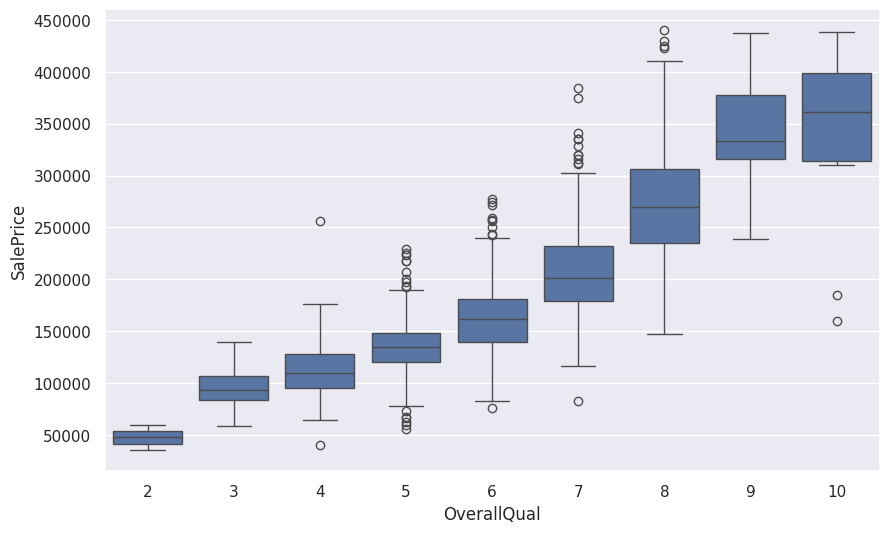

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='OverallQual', y="SalePrice")
plt.show()

Распределение `SalePrice` по году постройки:

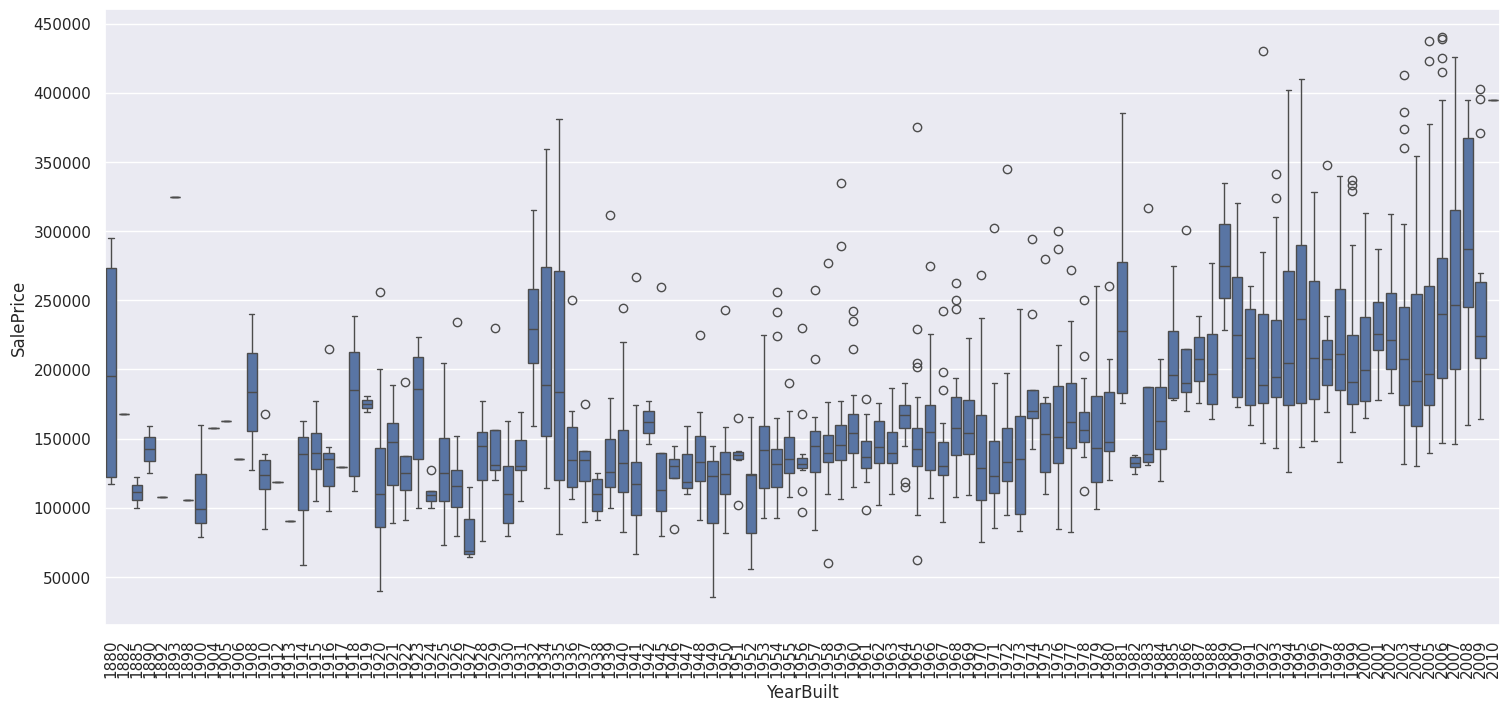

In [45]:
plt.figure(figsize=(18, 8))
sns.boxplot(data=data, x='YearBuilt', y="SalePrice")
plt.xticks(rotation=90)
plt.show()

### Задача 4

График выше — снова пример перегруженного графика. Как сделать лучше? Можно сгруппировать годы по периодам (3, 5, 10 лет и т.д.). Сделайте это и постройте график.

In [ ]:
# ваш код здесь

### Задача 5

Постройте boxplot'ы, violinplot'ы и/или pairplot'ы в разбивке по разным категориальным признакам.

In [ ]:
# ваш код здесь

# Распределение целевой переменной

Мы уже отмечали, что распределение целевой переменной похоже на нормальное. Но так ли это?

Подберём параметры нормального распределения по нашим данным и нарисуем теоретическую плотность вместе с реальной. Дополнительно построим **Q-Q plot** — квантили данных против квантилей нормального распределения: если распределение нормальное, точки лягут на прямую.

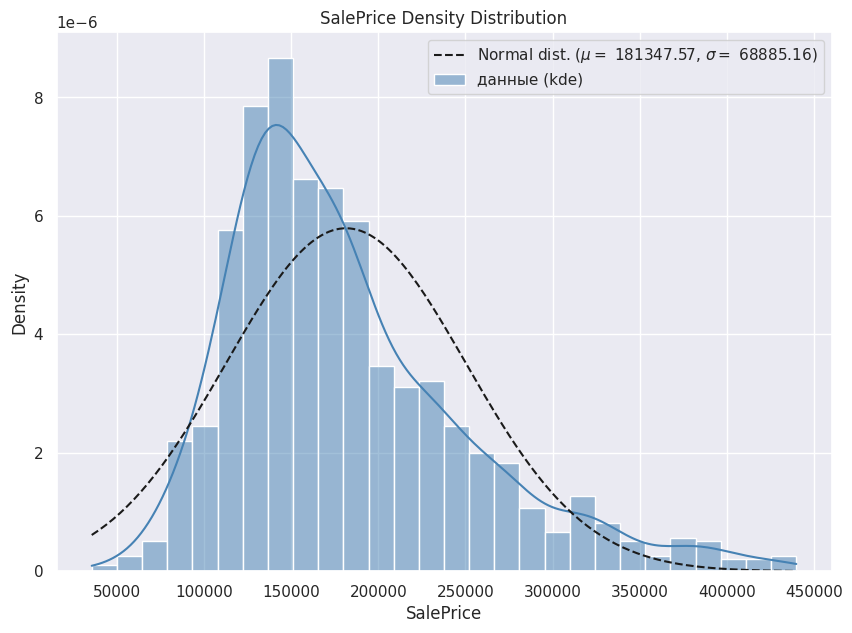

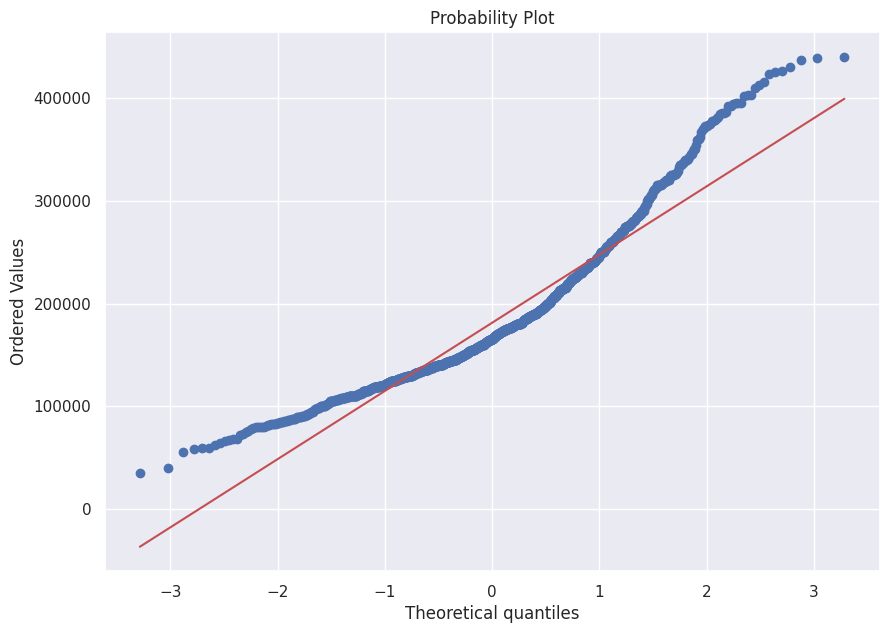

In [46]:
from scipy import stats
from scipy.stats import norm

# distplot(fit=norm) удалён из новых версий seaborn -> histplot + ручная кривая
s = data['SalePrice']
plt.figure(figsize=(10,7))
sns.histplot(s, kde=True, stat='density', color='steelblue', label='данные (kde)')
# подбираем параметры нормального распределения и рисуем его плотность поверх
(mu, sigma) = norm.fit(s)
x = np.linspace(s.min(), s.max(), 200)
plt.plot(x, norm.pdf(x, mu, sigma), 'k--', label=r'Normal dist. ($\mu=$ {:.2f}, $\sigma=$ {:.2f})'.format(mu, sigma))
plt.legend(loc='best'); plt.ylabel('Density'); plt.title('SalePrice Density Distribution')

# Q-Q plot: если распределение нормальное, точки лягут на прямую
plt.figure(figsize=(10,7))
stats.probplot(s, plot=plt)
plt.show()

Как видно, распределение не совсем нормальное: оно скошено вправо и имеет более высокую плотность в центре, чем теоретическое нормальное. На Q-Q plot хвосты отклоняются от прямой. Сделаем **монотонное преобразование** целевой переменной и посмотрим, станет ли лучше:

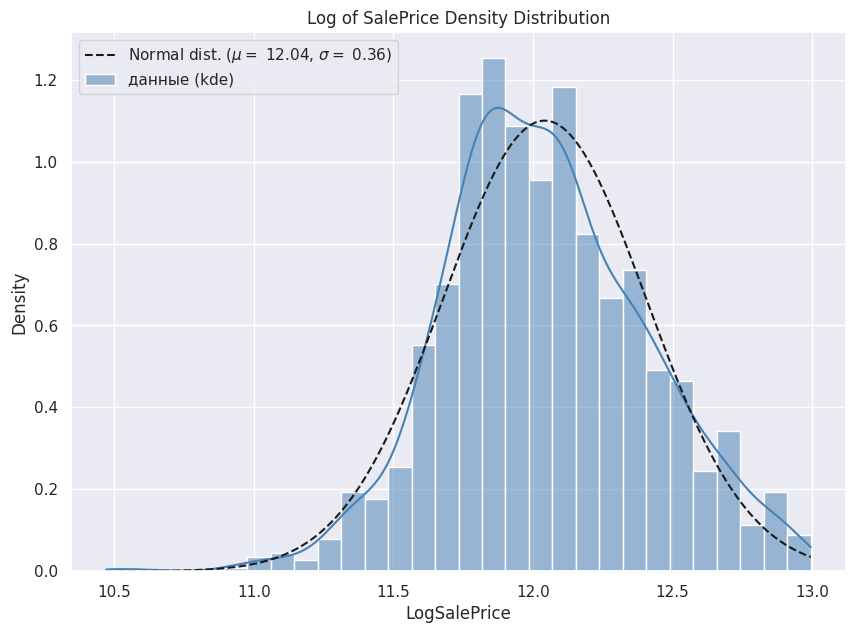

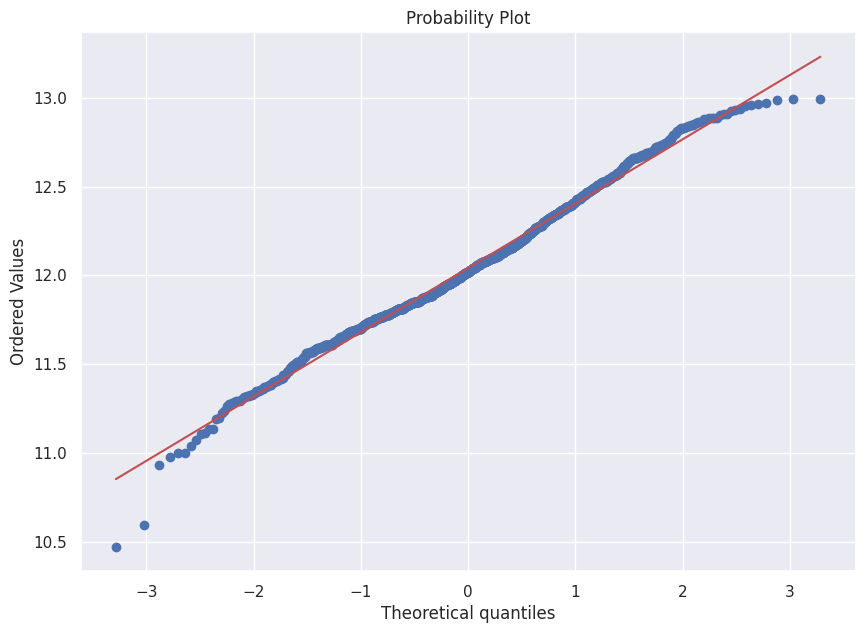

In [47]:
# берём логарифм цены (log1p = log(1 + x), безопасен для нулей)
data['LogSalePrice'] = np.log1p(data.SalePrice)

s = data['LogSalePrice']
plt.figure(figsize=(10,7))
sns.histplot(s, kde=True, stat='density', color='steelblue', label='данные (kde)')
# подбираем параметры нормального распределения и рисуем его плотность поверх
(mu, sigma) = norm.fit(s)
x = np.linspace(s.min(), s.max(), 200)
plt.plot(x, norm.pdf(x, mu, sigma), 'k--', label=r'Normal dist. ($\mu=$ {:.2f}, $\sigma=$ {:.2f})'.format(mu, sigma))
plt.legend(loc='best'); plt.ylabel('Density'); plt.title('Log of SalePrice Density Distribution')

# Q-Q plot: если распределение нормальное, точки лягут на прямую
plt.figure(figsize=(10,7))
stats.probplot(s, plot=plt)
plt.show()

Гораздо лучше :)

Логарифм — это способ 3 из списка методов обработки выбросов: хвост сжат, экстремальные значения остались, но перестали доминировать. Именно на `LogSalePrice` мы и будем учить модель.

# Разбиение на train и test + работа с числовыми признаками

Разделим данные на **обучающую** и **тестовую** выборки. Для простоты не будем выделять отдельную валидационную выборку (хотя обычно это стоит делать: она нужна для подбора гиперпараметров — параметров, которые нельзя подобрать по обучающей выборке). Отделим также целевую переменную от признаков.

⚠️ Из признаков нужно убрать всё, что **вычислено из таргета**: `SalePrice`, `LogSalePrice` и `PriceGroups`. Иначе получим утечку — модель «подсмотрит» ответ. (В исходной версии семинара `PriceGroups` оставался в `X`; он не попадал в модель только по счастливой случайности — из-за типа `category`.)

In [48]:
from sklearn.model_selection import train_test_split

y = data['LogSalePrice']
X = data.drop(columns=['SalePrice', 'LogSalePrice', 'PriceGroups'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
X_train.shape, X_test.shape

((949, 73), (408, 73))

Сначала посмотрим на значения **целевой переменной** в train:

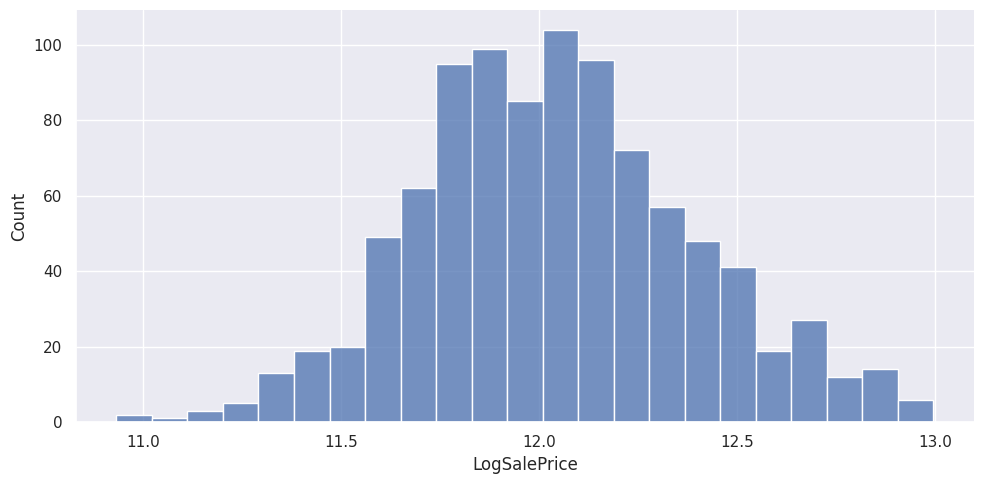

In [49]:
sns.displot(y_train, height=5, aspect=2);

Судя по гистограмме, есть примеры с нетипично высокой стоимостью — это может мешать, если **функция потерь** *слишком чувствительна к выбросам*. Позже посмотрим, как минимизировать ущерб.

Мы хотим обучить классическую **линейную регрессию**, поэтому полезно найти признаки, «наиболее линейно» связанные с таргетом — посмотреть на **коэффициент корреляции Пирсона** между признаками и целевой переменной. Не все признаки числовые, так что пока рассматриваем только числовые.

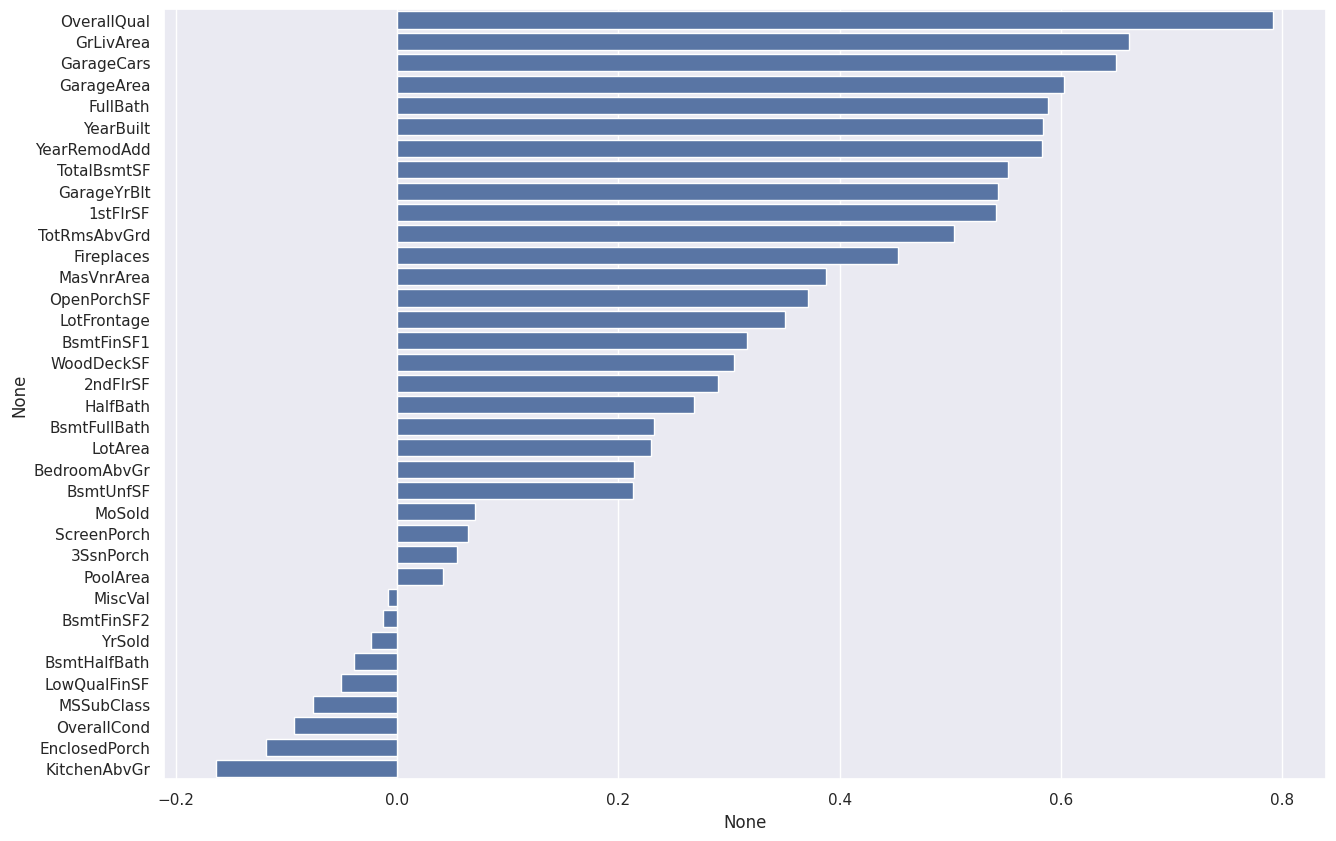

In [50]:
numeric_data = X_train.select_dtypes('number')
numeric_data_mean = numeric_data.mean()
numeric_features = numeric_data.columns

# заполняем пропуски средним, посчитанным ТОЛЬКО по train (на test — те же значения)
X_train = X_train.fillna(numeric_data_mean)
X_test = X_test.fillna(numeric_data_mean)

correlations = X_train[numeric_features].corrwith(y_train).sort_values(ascending=False)

plt.figure(figsize=(15, 10))
sns.barplot(y=correlations.index, x=correlations)
plt.show()

Посмотрим на признаки из верхней части списка: нарисуем зависимость таргета от каждого. На таком графике каждая точка — пара «признак, таргет» (это **scatter plot**).

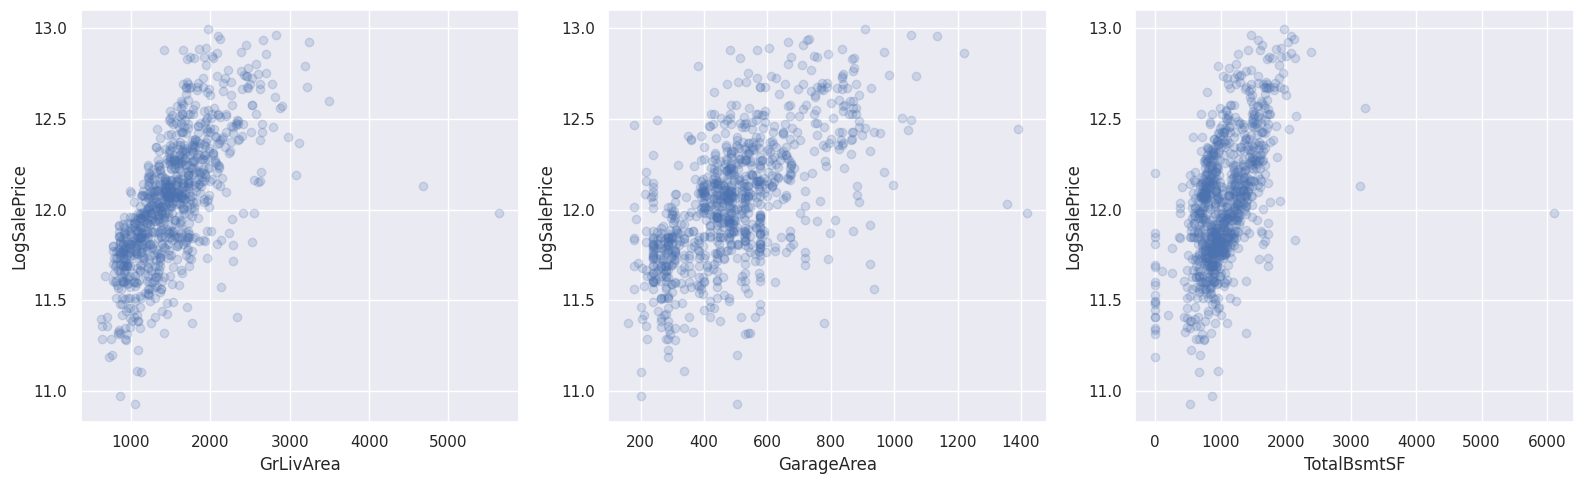

In [51]:
fig, axs = plt.subplots(figsize=(16, 5), ncols=3)
for i, feature in enumerate(['GrLivArea', 'GarageArea', 'TotalBsmtSF']):
    axs[i].scatter(X_train[feature], y_train, alpha=0.2)
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('LogSalePrice')
plt.tight_layout()
plt.show()

Видим, что между этими признаками и таргетом действительно есть линейная зависимость.

# Наша первая модель

У моделей из sklearn есть методы **fit** и **predict**. Первый принимает обучающую выборку и вектор целевой переменной и обучает модель; второй, вызванный после обучения, возвращает предсказание на выборке. Обучим первую модель на числовых признаках.

О метрике: модель предсказывает **логарифм** цены, поэтому RMSE считается в логарифмах. `exp(RMSE)` — это не ошибка в долларах, а **типичный множитель ошибки**: например, 1.15 означает, что предсказание в среднем промахивается примерно на 15% в ту или другую сторону.

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

def report(y_train, y_train_pred, y_test, y_pred):
    print('Train RMSE (log) = %.4f  |  exp = %.4f' % (root_mean_squared_error(y_train, y_train_pred), np.exp(root_mean_squared_error(y_train, y_train_pred))))
    print('Test  RMSE (log) = %.4f  |  exp = %.4f' % (root_mean_squared_error(y_test, y_pred), np.exp(root_mean_squared_error(y_test, y_pred))))

model = LinearRegression()
model.fit(X_train[numeric_features], y_train)
y_pred = model.predict(X_test[numeric_features])
y_train_pred = model.predict(X_train[numeric_features])

report(y_train, y_train_pred, y_test, y_pred)

Train RMSE (log) = 0.1396  |  exp = 1.1498
Test  RMSE (log) = 0.1446  |  exp = 1.1556


In [53]:
# коэффициенты модели: по ним пока нельзя судить о важности признаков — масштабы признаков разные
pd.Series(model.coef_, index=numeric_features).sort_values(key=abs, ascending=False).head(10)

,0
KitchenAbvGr,-0.107702
OverallQual,0.081463
GarageCars,0.077894
BsmtFullBath,0.057770
Fireplaces,0.056074
OverallCond,0.039791
FullBath,0.028412
BsmtHalfBath,0.022113
TotRmsAbvGrd,0.018400
YrSold,-0.006247


Мы обучили первую модель и посчитали её качество на тесте!

Теперь **отмасштабируем** признаки перед обучением.

Для этого используем трансформер **StandardScaler**. У трансформеров в sklearn есть методы **fit** и **transform** (а также fit_transform). fit принимает обучающую выборку и вычисляет по ней нужные величины (для StandardScaler — среднее и стандартное отклонение каждого признака). transform применяет преобразование к переданной выборке.

Для линейной регрессии без регуляризации масштабирование не меняет предсказания (метрика останется той же), но делает **коэффициенты сравнимыми** между собой — и оно обязательно для регуляризованных моделей (Ridge, Lasso) и градиентных методов.

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])   # fit по train
X_test_scaled = scaler.transform(X_test[numeric_features])         # только transform по test

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_train_pred = model.predict(X_train_scaled)

report(y_train, y_train_pred, y_test, y_pred)

Train RMSE (log) = 0.1396  |  exp = 1.1498
Test  RMSE (log) = 0.1446  |  exp = 1.1556


In [55]:
# статистики, которые scaler запомнил на train
pd.DataFrame({'mean': scaler.mean_, 'std': np.sqrt(scaler.var_)}, index=numeric_features).head()

,mean,std
MSSubClass,56.617492,41.213701
LotFrontage,70.537408,22.596705
LotArea,10443.926238,9783.439754
OverallQual,6.149631,1.277491
OverallCond,5.589041,1.090106


Теперь воспользуемся очень удобным классом **Pipeline**. Обучение модели — это обычно последовательность действий с train и test (например, сначала масштабировать (train — *fit_transform*, test — *transform*), затем обучить модель (train — *fit*, test — *predict*)). Pipeline хранит эту последовательность и корректно обрабатывает оба типа выборок — так невозможно случайно сделать `fit` на тесте.

In [56]:
from sklearn.pipeline import Pipeline

simple_pipeline = Pipeline([
    ('scaling', StandardScaler()),
    ('regression', LinearRegression())
])

model = simple_pipeline.fit(X_train[numeric_features], y_train)
y_pred = model.predict(X_test[numeric_features])
print('Test RMSE (log) = %.4f  |  exp = %.4f' % (root_mean_squared_error(y_test, y_pred), np.exp(root_mean_squared_error(y_test, y_pred))))

Test RMSE (log) = 0.1446  |  exp = 1.1556


# Работа с категориальными признаками

Сейчас мы используем не всю информацию из данных — часть признаков просто выброшена. Эти признаки *закодированы строками*, каждая обозначает **некоторую категорию**. Такие признаки называют **категориальными**. Выделим их и сразу заполним пропуски специальным значением (сам факт пропуска может быть полезным признаком).

In [57]:
# НЕ через dtypes == 'object': в pandas 3 строковые столбцы имеют dtype 'str', и такой фильтр вернул бы пустой список
categorical = X_train.select_dtypes(exclude='number').columns.tolist()
X_train[categorical] = X_train[categorical].fillna('NotGiven')
X_test[categorical] = X_test[categorical].fillna('NotGiven')
len(categorical), categorical[:10]

(37,
 ['MSZoning',
  'Street',
  'LotShape',
  'LandContour',
  'Utilities',
  'LotConfig',
  'LandSlope',
  'Neighborhood',
  'Condition1',
  'Condition2'])

In [58]:
X_train[categorical].sample(5)

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,Electrical,KitchenQual,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
754,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,...,SBrkr,Ex,Typ,Attchd,RFn,TA,TA,Y,WD,Normal
732,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Timber,Norm,Norm,...,SBrkr,Gd,Typ,Attchd,Fin,TA,TA,Y,WD,Normal
695,RM,Pave,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Norm,Norm,...,SBrkr,TA,Typ,Detchd,Unf,TA,TA,Y,WD,Normal
665,RL,Pave,IR2,Lvl,AllPub,CulDSac,Gtl,Somerst,RRAn,Norm,...,SBrkr,Ex,Typ,Attchd,Fin,TA,TA,Y,New,Partial
1179,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,Crawfor,Norm,Norm,...,SBrkr,TA,Typ,Detchd,Unf,Fa,TA,Y,WD,Normal


Теперь категориальные признаки нужно закодировать числами. Два стандартных трансформера sklearn — **OrdinalEncoder** (просто нумерует значения натуральными числами) и **OneHotEncoder**.

OneHotEncoder сопоставляет каждому значению признака вектор из нулей и одной единицы (на позиции, соответствующей принятому значению).

`handle_unknown='ignore'` нужен, чтобы пайплайн не падал, если в test встретится категория, которой не было в train (все нули в OHE-векторе).

In [59]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', LinearRegression())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Test RMSE (log) = %.4f  |  exp = %.4f' % (root_mean_squared_error(y_test, y_pred), np.exp(root_mean_squared_error(y_test, y_pred))))

Test RMSE (log) = 0.1283  |  exp = 1.1369


Тестовая ошибка уменьшилась! На сегодня всё :)

Материалы, использованные и адаптированные для sklearn-части семинара:
- Семинар 2 курса ML Евгения Соколова на ПМИ для 3-го курса https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/seminars/sem02-sklearn-linregr.ipynb
- Официальная документация scikit-learn https://scikit-learn.org/stable/index.html